# Vorbereitung des Teilexperiment 1

Aufbereitung der Daten für den ersten Experimentendurchlauf. Gestützt auf das Dataset vrdu ad-buy-form Korpus zur internen Vergleichbarkeit der Experimentbedingungen in einer isolierten Domäne (inter Domain).

In [38]:
import os

RAW_DATA_PATH = "../data/raw/vrdu/ad-buy-form/"
OUTPUT_DIR = "../data/processed/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [39]:
import pandas as pd

df_ad_buy_form = pd.read_json(
    "../data/raw/vrdu/ad-buy-form/main/dataset.jsonl", lines=True
)

df_ad_buy_form.head(5)

,filename,file_path,ocr,annotations
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,./pdfs/00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,{'text': 'Page 1 of 2 INVOICE FOX Remit Addres...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662..."
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,./pdfs/00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,{'text': 'Page 1 of 1 INVOICE DUE ATE 2436316-...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677..."
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,./pdfs/00c3353e-a25f-574a-a9db-39a41579895a.pdf,{'text': 'Print Date 02/28/20 14:21:20 Page 1 ...,"[[contract_num, [['14086\n', [0, 0.27917981000..."
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,./pdfs/01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,{'text': 'Page 1 of 4 INVOICE Advertiser 4 Rem...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0..."
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,./pdfs/0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,{'text': 'Contract # Date Entered Schedule Dat...,"[[contract_num, [['575746\n', [0, 0.3472609200..."


### Auslesen der Annotationen

In [40]:
ad_buy_meta = pd.read_json("../data/raw/vrdu/ad-buy-form/main/meta.json")

line_items_df = ad_buy_meta[ad_buy_meta["entity_appearance_pattern"] == "line_item"]

line_item_keys = line_items_df.index.tolist()

line_item_keys

['channel',
 'program_desc',
 'program_start_date',
 'program_end_date',
 'sub_amount']

In [41]:
import pandas as pd

processed_docs = []


def extract_clean_text(data):
    """Rekursive Hilfsfunktion: Zieht alle Texte heraus, ignoriert Bounding Boxes."""
    if isinstance(data, str):
        return data.replace("\n", " ").strip()
    elif isinstance(data, list):
        texts = []
        for item in data:
            # Bounding-Boxen überspringen (Listen, die mit Zahlen beginnen)
            if (
                isinstance(item, list)
                and len(item) > 0
                and isinstance(item[0], (int, float))
            ):
                continue
            extracted = extract_clean_text(item)
            if extracted:
                texts.append(extracted)
        return " ".join(texts)
    return ""


# Hauptschleife über alle Dokumente
for doc in df_ad_buy_form.to_dict(orient="records"):

    annotations_list = doc.get("annotations", [])
    ground_truth = {}
    line_items_extracted = []

    if isinstance(annotations_list, list):
        for annotation in annotations_list:
            # Ein valider Annotation-Block braucht mindestens den Key und den Value
            if not isinstance(annotation, list) or len(annotation) < 2:
                continue

            entity_keys = annotation[0]
            entity_values = annotation[1]

            # Flache Felder
            if isinstance(entity_keys, str):
                field_name = entity_keys
                clean_value = extract_clean_text(entity_values)

                # Falls VRDU ein Feld auf mehreren Seiten findet
                if field_name in ground_truth and ground_truth[field_name]:
                    ground_truth[field_name] += " " + clean_value
                else:
                    ground_truth[field_name] = clean_value

            # Line Items / Tabellen (Hierarchical Entities)
            elif isinstance(entity_keys, list):
                headers = entity_keys
                rows = entity_values

                if isinstance(rows, list):
                    for row in rows:
                        row_dict = {}
                        if isinstance(row, list):
                            # Jedes Element in der Zeile dem passenden Header zuordnen
                            for idx, header in enumerate(headers):
                                if idx < len(row):
                                    row_dict[header] = extract_clean_text(row[idx])
                            line_items_extracted.append(row_dict)

    if line_items_extracted:
        ground_truth["line_items"] = line_items_extracted
        has_line_items = True
    else:
        has_line_items = False

    property_clean = ground_truth.get("property", "UNKNOWN")

    # Fertiges, sauberes Dokumenten-Objekt
    processed_docs.append(
        {
            "doc_id": doc.get("filename", "unknown_id"),
            "property": property_clean,  
            "has_line_items": has_line_items,
            "ground_truth": ground_truth,
            "raw_doc": doc,
            "annotations": annotations_list,
            "ocr_text": extract_clean_text(doc.get("ocr", {}).get("text", "")),
        }
    )

df_processed = pd.DataFrame(processed_docs)

In [42]:
df_processed.head(5)

,doc_id,property,has_line_items,ground_truth,raw_doc,annotations,ocr_text
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,KMSP KMSP KMSP KMSP,True,"{'property': 'KMSP KMSP KMSP KMSP', 'tv_addres...",{'filename': '00a83bbc-0101-f092-4bd7-e75f315e...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662...",Page 1 of 2 INVOICE FOX Remit Address: KMSP 46...
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,WXXA WXXA,True,"{'property': 'WXXA WXXA', 'tv_address': 'PO Bo...",{'filename': '00c29ad8-c88b-b3bb-1a39-3267e47c...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677...",Page 1 of 1 INVOICE DUE ATE 2436316-1 POL/FWD....
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,WSIL-TV,True,"{'contract_num': '14086', 'product': 'Mike Car...",{'filename': '00c3353e-a25f-574a-a9db-39a41579...,"[[contract_num, [['14086\n', [0, 0.27917981000...",Print Date 02/28/20 14:21:20 Page 1 of 1 ORDER...
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,KCNC-TV KCNC-TV KCNC-TV KCNC-TV KCNC-TV KCNC-T...,True,{'property': 'KCNC-TV KCNC-TV KCNC-TV KCNC-TV ...,{'filename': '01250d60-2a0a-0c93-5a18-9f1f195f...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0...",Page 1 of 4 INVOICE Advertiser 4 Remit Address...
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,KBJR Television Inc,True,"{'contract_num': '575746', 'flight_from': '05/...",{'filename': '0179ed96-6b64-eb8b-07c1-3214262d...,"[[contract_num, [['575746\n', [0, 0.3472609200...",Contract # Date Entered Schedule Dates Last Mo...


In [43]:
def count_annotation_spans(annotations_list):
    """
    Zählt die Gesamtanzahl aller annotierten Werteinstanzen in einem Dokument.
    - Flat fields: zählt jeden OCR-Span
    - Line items:  zählt jede Tabellenzeile
    Gleiche Logik für ad-buy UND registration.
    """
    if not isinstance(annotations_list, list):
        return 0
    count = 0
    for ann in annotations_list:
        if not isinstance(ann, list) or len(ann) < 2:
            continue
        if isinstance(ann[0], str):  # Flat field
            count += len(ann[1]) if isinstance(ann[1], list) else 1
        elif isinstance(ann[0], list):  # Line item (Hierarchical)
            count += len(ann[1]) if isinstance(ann[1], list) else 1
    return count


df_processed["annotation_count"] = df_processed["raw_doc"].apply(
    lambda doc: count_annotation_spans(doc.get("annotations", []))
)

# Terzile berechnen
p33 = df_processed["annotation_count"].quantile(0.33)
p66 = df_processed["annotation_count"].quantile(0.66)

df_processed["complexity"] = df_processed["annotation_count"].apply(
    lambda c: "L1" if c <= p33 else ("L2" if c <= p66 else "L3")
)

print(df_processed["complexity"].value_counts())
print(f"\nTerzilgrenzen: L1 ≤ {p33:.0f}, L2 ≤ {p66:.0f}, L3 > {p66:.0f}")
print(df_processed.groupby("complexity")["annotation_count"].describe())

complexity
L1    224
L3    210
L2    207
Name: count, dtype: int64

Terzilgrenzen: L1 ≤ 19, L2 ≤ 34, L3 > 34
            count       mean        std   min   25%   50%    75%    max
complexity                                                             
L1          224.0  12.915179   3.259610   1.0  11.0  12.0  15.00   19.0
L2          207.0  26.888889   4.186458  20.0  23.5  27.0  30.00   34.0
L3          210.0  51.214286  17.125397  35.0  39.0  48.0  56.75  154.0


# Auswertung des Splits

In [44]:
df_processed.has_line_items.groupby(df_processed.complexity).value_counts()

complexity  has_line_items
L1          True              219
            False               5
L2          True              207
L3          True              210
Name: count, dtype: int64

Fast alle Dokumente bis auf 5 in L1 enthalten auch Tabellarische Daten und sind somit nicht für die Einteilung in Komplexitätsstufen geeignet.

In [45]:
def calculate_text_metrics(text):
    """Berechnet Wortanzahl und Zeichenanzahl aus dem OCR-Text."""

    if not isinstance(text, str):
        return {"word_count": 0, "char_count": 0}

    words = text.split()
    return {"word_count": len(words), "char_count": len(text)}

metrics_df = df_processed["ocr_text"].apply(calculate_text_metrics).apply(pd.Series)
df_processed = pd.concat([df_processed, metrics_df], axis=1)

print("\n Durchschnittliche Wortanzahl (Word Count) pro Komplexität")
print(df_processed.groupby("complexity")["word_count"].describe())



 Durchschnittliche Wortanzahl (Word Count) pro Komplexität
            count         mean          std    min     25%     50%      75%  \
complexity                                                                    
L1          224.0   645.616071  1009.409366   90.0   266.0   334.5   483.75   
L2          207.0  1164.975845  1093.281999  347.0   613.0   776.0  1219.00   
L3          210.0  1764.752381  1265.812437  618.0  1089.0  1315.5  1788.00   

                max  
complexity           
L1          10393.0  
L2          11057.0  
L3          11519.0  


In [46]:
print("\nDurchschnittliche Zeichenanzahl (Char Count) pro Komplexität")
print(df_processed.groupby("complexity")["char_count"].describe())


Durchschnittliche Zeichenanzahl (Char Count) pro Komplexität
            count          mean          std     min     25%     50%  \
complexity                                                             
L1          224.0   4092.437500  6528.550934   644.0  1707.5  2156.0   
L2          207.0   7243.386473  7082.858816  2414.0  3675.0  4750.0   
L3          210.0  10936.261905  8222.364767  3941.0  6438.0  8073.0   

                 75%      max  
complexity                     
L1           3143.25  68923.0  
L2           7512.50  72947.0  
L3          11217.25  75843.0  


In [47]:
df_processed.head(5)

,doc_id,property,has_line_items,ground_truth,raw_doc,annotations,ocr_text,annotation_count,complexity,word_count,char_count
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,KMSP KMSP KMSP KMSP,True,"{'property': 'KMSP KMSP KMSP KMSP', 'tv_addres...",{'filename': '00a83bbc-0101-f092-4bd7-e75f315e...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662...",Page 1 of 2 INVOICE FOX Remit Address: KMSP 46...,25,L2,739,4524
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,WXXA WXXA,True,"{'property': 'WXXA WXXA', 'tv_address': 'PO Bo...",{'filename': '00c29ad8-c88b-b3bb-1a39-3267e47c...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677...",Page 1 of 1 INVOICE DUE ATE 2436316-1 POL/FWD....,11,L1,200,1260
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,WSIL-TV,True,"{'contract_num': '14086', 'product': 'Mike Car...",{'filename': '00c3353e-a25f-574a-a9db-39a41579...,"[[contract_num, [['14086\n', [0, 0.27917981000...",Print Date 02/28/20 14:21:20 Page 1 of 1 ORDER...,11,L1,241,1506
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,KCNC-TV KCNC-TV KCNC-TV KCNC-TV KCNC-TV KCNC-T...,True,{'property': 'KCNC-TV KCNC-TV KCNC-TV KCNC-TV ...,{'filename': '01250d60-2a0a-0c93-5a18-9f1f195f...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0...",Page 1 of 4 INVOICE Advertiser 4 Remit Address...,51,L3,1117,6723
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,KBJR Television Inc,True,"{'contract_num': '575746', 'flight_from': '05/...",{'filename': '0179ed96-6b64-eb8b-07c1-3214262d...,"[[contract_num, [['575746\n', [0, 0.3472609200...",Contract # Date Entered Schedule Dates Last Mo...,18,L1,385,2348


Über die 3 Schwierigkeitsstufen zeigt sich ein Anstieg der Informationsdichte. Dies kann über die ansteigende Zeichen und Wortdichte erfasst werden, sowie durch den höheren Anteil an Annoatationen, die im Experiment extrahiert werden.

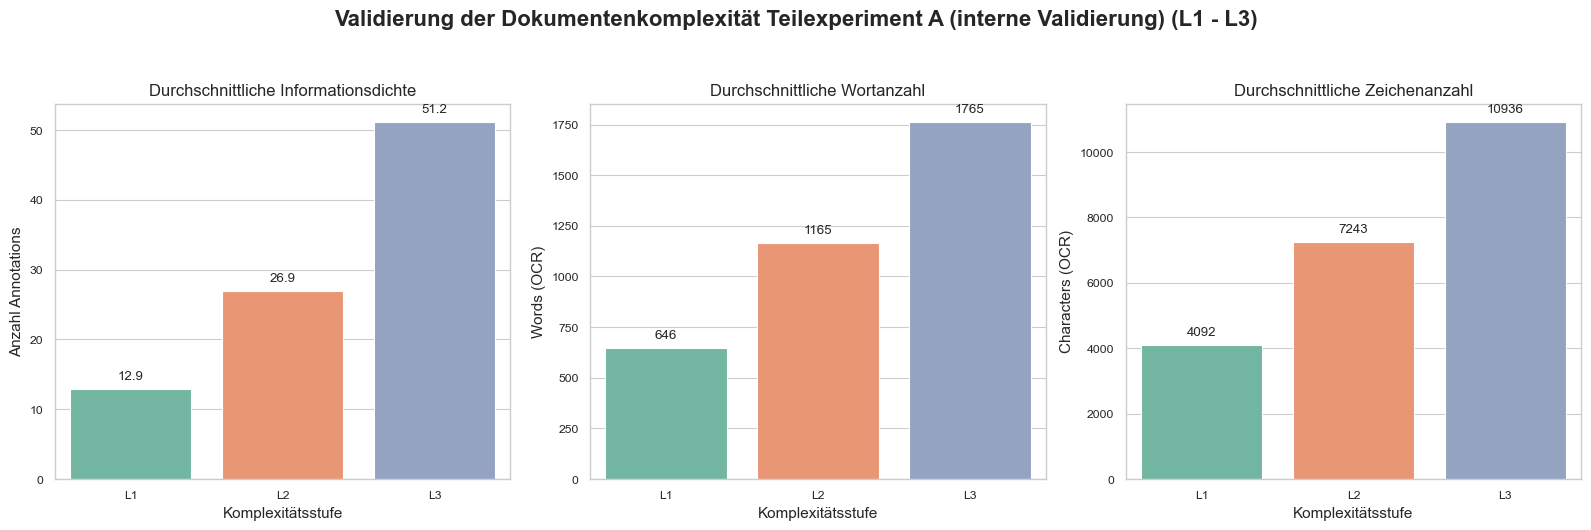

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped_means = (
    df_processed.groupby("complexity")[["annotation_count", "word_count", "char_count"]]
    .mean()
    .reset_index()
)

grouped_means["complexity"] = pd.Categorical(
    grouped_means["complexity"], categories=["L1", "L2", "L3"], ordered=True
)
grouped_means = grouped_means.sort_values("complexity")

sns.set_theme(style="whitegrid", context="paper")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Validierung der Dokumentenkomplexität Teilexperiment A (interne Validierung) (L1 - L3)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

# Durchschnittliche Annotations
sns.barplot(
    ax=axes[0],
    data=grouped_means,
    x="complexity",
    y="annotation_count",
    hue="complexity",
    palette="Set2",
    legend=False,
    dodge=False,
)
axes[0].set_title("Durchschnittliche Informationsdichte", fontsize=12)
axes[0].set_ylabel("Anzahl Annotations", fontsize=11)
axes[0].set_xlabel("Komplexitätsstufe", fontsize=11)

for p in axes[0].patches:
    axes[0].annotate(
        format(p.get_height(), ".1f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
    )

# Durchschnittlicher Word Count
sns.barplot(
    ax=axes[1],
    data=grouped_means,
    x="complexity",
    y="word_count",
    hue="complexity",
    palette="Set2",
    legend=False,
    dodge=False,
)
axes[1].set_title("Durchschnittliche Wortanzahl", fontsize=12)
axes[1].set_ylabel("Words (OCR)", fontsize=11)
axes[1].set_xlabel("Komplexitätsstufe", fontsize=11)
for p in axes[1].patches:
    axes[1].annotate(
        format(p.get_height(), ".0f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
    )

# Durchschnittlicher Char Count
sns.barplot(
    ax=axes[2],
    data=grouped_means,
    x="complexity",
    y="char_count",
    hue="complexity",
    palette="Set2",
    legend=False,
    dodge=False,
)
axes[2].set_title("Durchschnittliche Zeichenanzahl", fontsize=12)
axes[2].set_ylabel("Characters (OCR)", fontsize=11)
axes[2].set_xlabel("Komplexitätsstufe", fontsize=11)
for p in axes[2].patches:
    axes[2].annotate(
        format(p.get_height(), ".0f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

### Ziehung der Stichprobe

In [49]:
df_experiment = df_processed.groupby("complexity").sample(n=50, random_state=42)

df_experiment["complexity"] = pd.Categorical(
    df_experiment["complexity"], categories=["L1", "L2", "L3"], ordered=True
)

print(f"Finale Stichprobengröße für das Experiment: {len(df_experiment)}")
print(df_experiment["complexity"].value_counts())

Finale Stichprobengröße für das Experiment: 150
complexity
L1    50
L2    50
L3    50
Name: count, dtype: int64


## Statistische Auswertung der Stichprobenziehung

### Verteilung der Daten

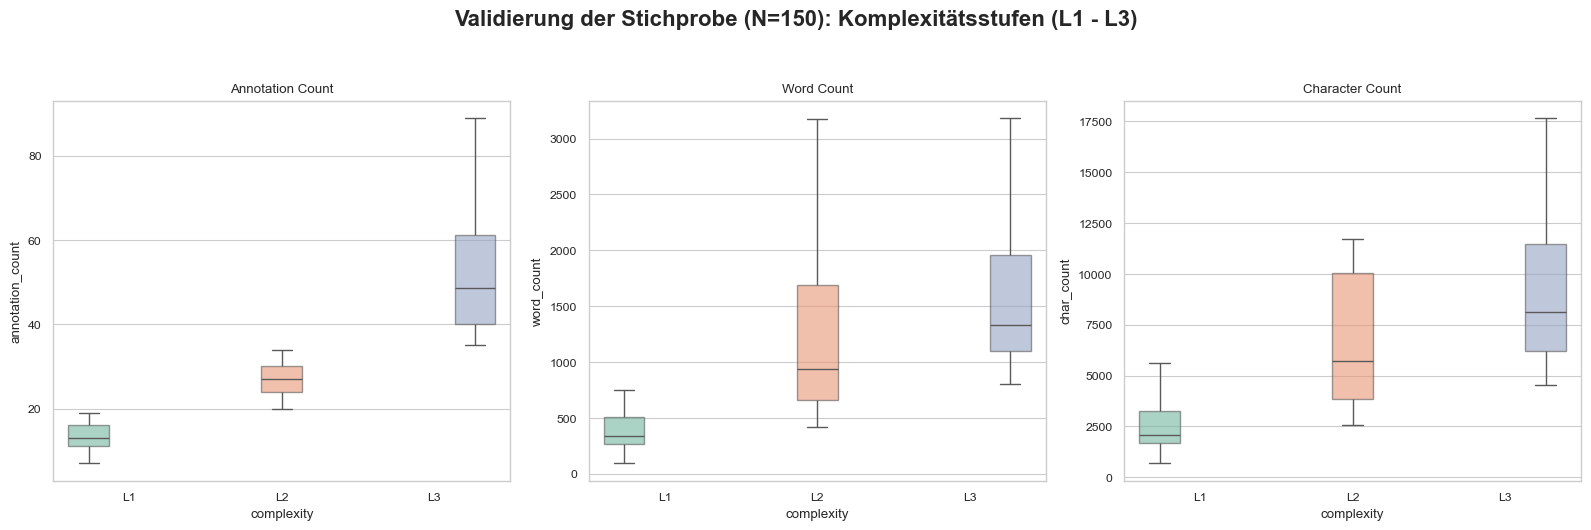

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Validierung der Stichprobe (N={len(df_experiment)}): Komplexitätsstufen (L1 - L3)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

palette = "Set2"

sns.boxplot(
    ax=axes[0],
    data=df_experiment,
    x="complexity",
    y="annotation_count",
    hue="complexity",
    palette=palette,
    legend=False,
    boxprops={"alpha": 0.6},
    showfliers=False,
)
axes[0].set_title("Annotation Count")

sns.boxplot(
    ax=axes[1],
    data=df_experiment,
    x="complexity",
    y="word_count",
    hue="complexity",
    palette=palette,
    legend=False,
    boxprops={"alpha": 0.6},
    showfliers=False,
)
axes[1].set_title("Word Count")

sns.boxplot(
    ax=axes[2],
    data=df_experiment,
    x="complexity",
    y="char_count",
    hue="complexity",
    palette=palette,
    legend=False,
    boxprops={"alpha": 0.6},
    showfliers=False,
)
axes[2].set_title("Character Count")

plt.tight_layout()
plt.show()

/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_69935/2802410835.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


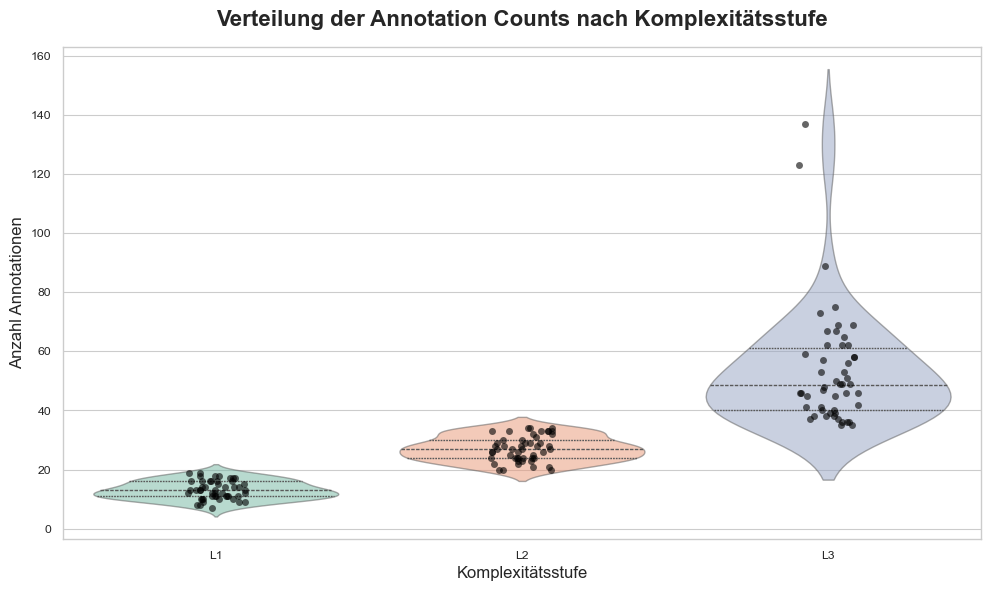

In [51]:
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(10, 6))

palette = "Set2"

# Der Violinplot zeigt die Form der Verteilung
sns.violinplot(
    data=df_experiment,
    x="complexity",
    y="annotation_count",
    palette=palette,
    inner="quartile", 
    alpha=0.5,
    order=["L1", "L2", "L3"],
)

# Der Stripplot legt die echten, einzelnen Datenpunkte darüber
sns.stripplot(
    data=df_experiment,
    x="complexity",
    y="annotation_count",
    color="black",
    alpha=0.6,  
    jitter=True,  
    size=5, 
    order=["L1", "L2", "L3"],
)

plt.title(
    "Verteilung der Annotation Counts nach Komplexitätsstufe",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Komplexitätsstufe", fontsize=12)
plt.ylabel("Anzahl Annotationen", fontsize=12)

plt.tight_layout()
plt.show()

Auf dem Plot ist zu sehen, dass L1 eine starke Ballung an seinem Mittel von 18 hat, während L2 höher liegt und eine nicht so starke Stauchung vorliet. In L3 ist eine sehr hohe Varianz zu erkennen, durch die starken Ausreiser bis größer als 140. 

### Untersuchung von L3 auf Normalverteilung

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

l1_counts = df_experiment[df_experiment["complexity"] == "L1"]["annotation_count"]
l2_counts = df_experiment[df_experiment["complexity"] == "L2"]["annotation_count"]
l3_counts = df_experiment[df_experiment["complexity"] == "L3"]["annotation_count"]

data_dict = {"L1": l1_counts, "L2": l2_counts, "L3": l3_counts}

results = []

for level, data in data_dict.items():
    # Shapiro-Wilk-Test (H0: Daten sind normalverteilt)
    stat, p_value = stats.shapiro(data)

    # Signifikanz prüfen (alpha = 0.05)
    is_normal = "Ja" if p_value >= 0.05 else "Nein"

    results.append(
        {
            "Komplexitätsstufe": level,
            "N (Stichprobe)": len(data),
            "W-Statistik": round(stat, 4),
            "p-Wert": f"{p_value:.5e}",
            "Normalverteilt (α=0.05)?": is_normal,
        }
    )

df_shapiro = pd.DataFrame(results)

print("Shapiro-Wilk-Test auf Normalverteilung")

display(df_shapiro)


Shapiro-Wilk-Test auf Normalverteilung


,Komplexitätsstufe,N (Stichprobe),W-Statistik,p-Wert,Normalverteilt (α=0.05)?
0,L1,50,0.9686,2.03155e-01,Ja
1,L2,50,0.9500,3.40594e-02,Nein
2,L3,50,0.7566,1.00210e-07,Nein


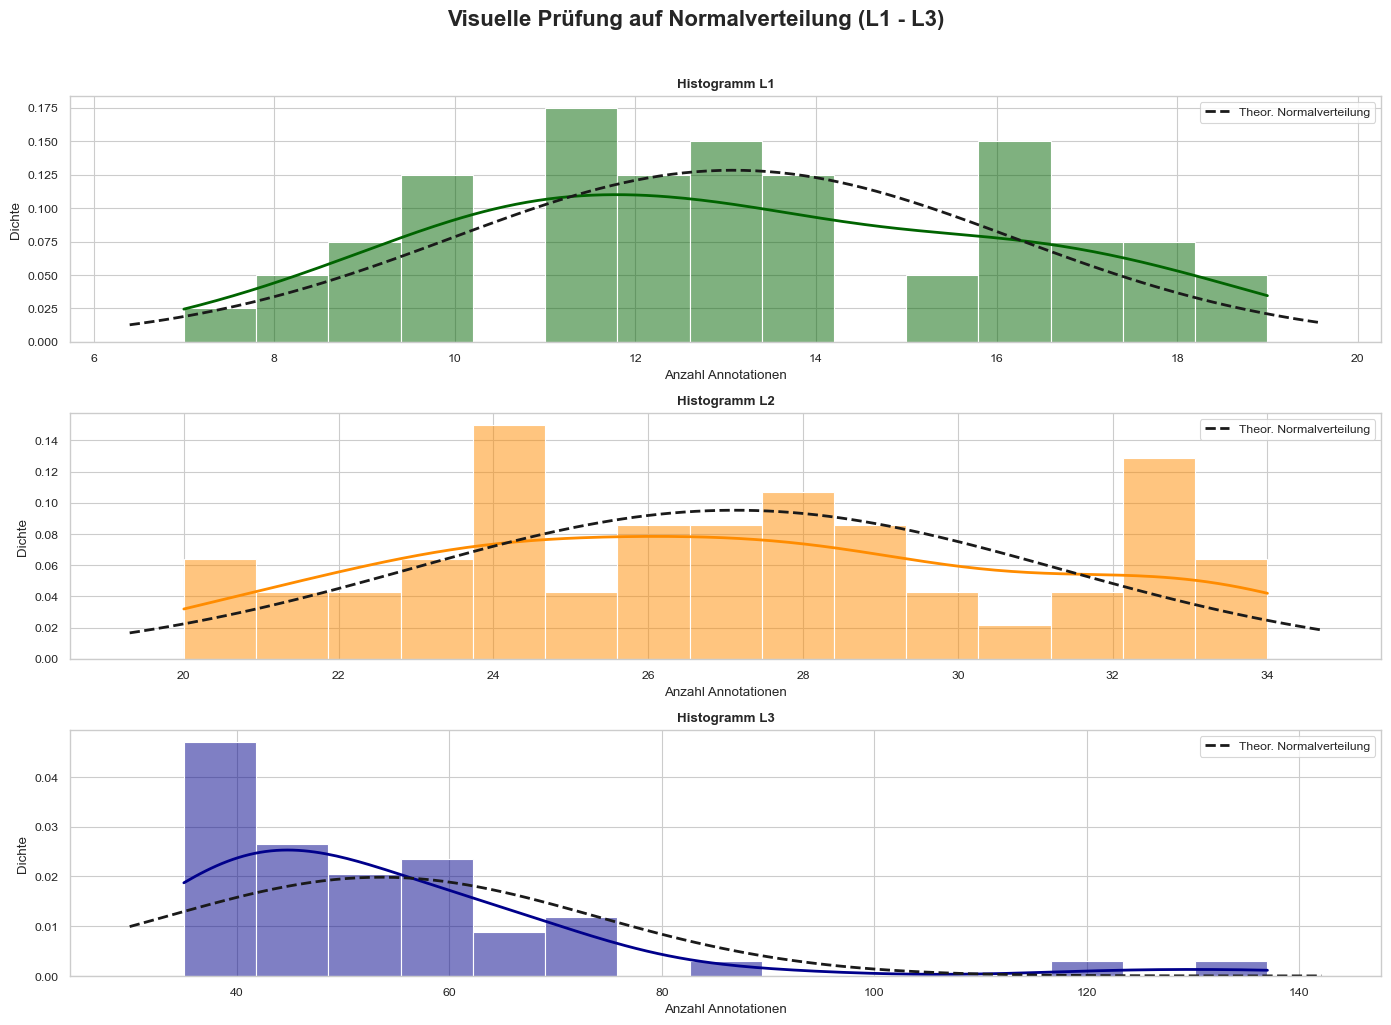

In [53]:
# Histogramm Plots mit theoretischer Normalverteilungskurve drüber
sns.set_theme(style="whitegrid", context="paper")


fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle(
    "Visuelle Prüfung auf Normalverteilung (L1 - L3)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

colors = ["green", "orange", "blue"]
colors = ["darkgreen", "darkorange", "darkblue"]

for i, (level, data) in enumerate(data_dict.items()):

    sns.histplot(
        data,
        kde=True,
        stat="density",
        ax=axes[i],
        color=colors[i],
        bins=15,
        line_kws={"linestyle": "-", "color": colors[i], "linewidth": 2},
    )
    axes[i].set_title(f"Histogramm {level}", fontweight="bold")
    axes[i].set_xlabel("Anzahl Annotationen")
    axes[i].set_ylabel("Dichte")

    # Theoretische Normalverteilungskurve drüberlegen
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, data.mean(), data.std())
    axes[i].plot(
        x, p, "k", linewidth=2, linestyle="--", label="Theor. Normalverteilung"
    )
    axes[i].legend()

plt.tight_layout()
plt.show()

### Statistischer Test der Unterschiede

Da die Hypothese der Normalverteilung abgelehnt werden muss, wird ein Shapiro Wilk Test angewendet, um die statisitsche Signifikanten Unterschiede zwischen den Gruppen zu beweisen.

In [54]:
import scipy.stats as stats
import scikit_posthocs as sp
import pandas as pd
from IPython.display import display

print("1. Kruskal-Wallis-Test (Globaler Unterschied)")

# Kruskal Wallist-Test mit stats berechnen
stat_kw, p_value_kw = stats.kruskal(l1_counts, l2_counts, l3_counts)

print(f"H-Statistik: {stat_kw:.4f}")
print(f"p-Wert:      {p_value_kw:.5e}\n")

if p_value_kw < 0.05:
    print(
        "-> Ergebnis: Signifikant! Mindestens eine der drei Gruppen unterscheidet sich signifikant von den anderen."
    )
    print("-> Gehe über zum Post-Hoc-Test, um die genauen Paare zu finden...\n")

    print("2. Dunn's Post-Hoc-Test (Paarweiser Vergleich)")

    # Dunn-Test berechnen (Bonferroni-Korrektur gegen Alpha-Fehler-Kumulierung)
    # Wir nutzen hier deinen Haupt-DataFrame df_experiment
    posthoc_matrix = sp.posthoc_dunn(
        df_experiment,
        val_col="annotation_count",
        group_col="complexity",
        p_adjust="bonferroni",
    )

    posthoc_matrix_rounded = posthoc_matrix.round(5)

    display(posthoc_matrix_rounded)

else:
    print(
        "-> Ergebnis: Nicht signifikant. Es gibt keine belegbaren Unterschiede zwischen den Gruppen."
    )
    print("-> Ein Post-Hoc-Test ist daher nicht zulässig/notwendig.")

1. Kruskal-Wallis-Test (Globaler Unterschied)
H-Statistik: 132.5434
p-Wert:      1.65411e-29

-> Ergebnis: Signifikant! Mindestens eine der drei Gruppen unterscheidet sich signifikant von den anderen.
-> Gehe über zum Post-Hoc-Test, um die genauen Paare zu finden...

2. Dunn's Post-Hoc-Test (Paarweiser Vergleich)


,L1,L2,L3
L1,1.0,0.0,0.0
L2,0.0,1.0,0.0
L3,0.0,0.0,1.0


Die Tabelle zeigt die p-Werte für jeden direkten Vergleich (z.B. Zeile L1, Spalte L3). Ist ein Wert kleiner als 0.05, ist der Unterschied zwischen diesen beiden Gruppen statistisch signifikant.

Die Unterschiede zwischen allen drei Gruppen sind nach der Post-Hoc Analyse signifikant.

ANOVA-Ergebnis für Annotations per Word: F=2.72, p-value=0.06663


/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_69935/202407144.py:33: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


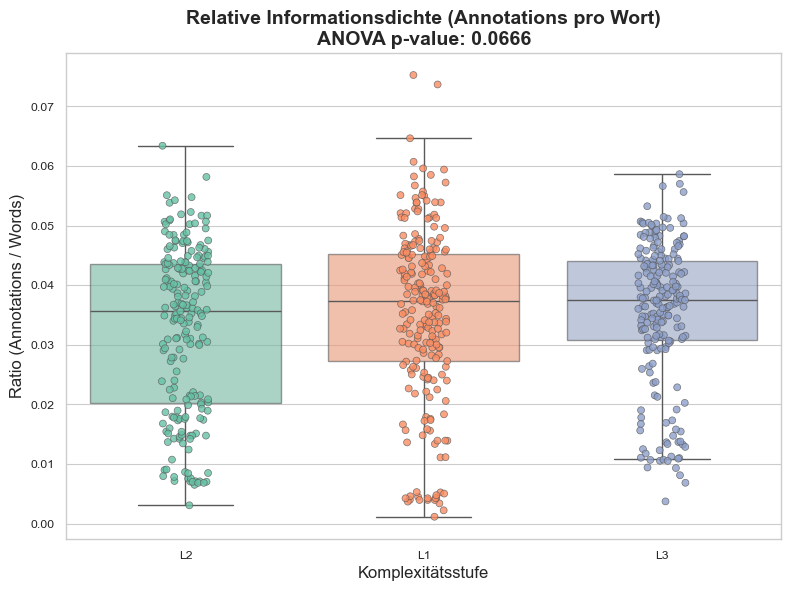

In [55]:
from scipy import stats

df_processed["annotations_per_word"] = (
    df_processed["annotation_count"] / df_processed["word_count"]
)

# 2. ANOVA berechnen (Gibt es hier signifikante Unterschiede?)
l1_ratio = df_processed[df_processed["complexity"] == "L1"]["annotations_per_word"]
l2_ratio = df_processed[df_processed["complexity"] == "L2"]["annotations_per_word"]
l3_ratio = df_processed[df_processed["complexity"] == "L3"]["annotations_per_word"]

f_stat_ratio, p_value_ratio = stats.f_oneway(l1_ratio, l2_ratio, l3_ratio)
print(
    f"ANOVA-Ergebnis für Annotations per Word: F={f_stat_ratio:.2f}, p-value={p_value_ratio:.5f}"
)

# 3. Den Plot zeichnen
plt.figure(figsize=(8, 6))

# Boxplot (Hintergrund)
sns.boxplot(
    data=df_processed,
    x="complexity",
    y="annotations_per_word",
    hue="complexity",
    palette="Set2",
    legend=False,
    boxprops={"alpha": 0.6},
    showfliers=False,
)

# Stripplot (Punkte im Vordergrund)
sns.stripplot(
    data=df_processed,
    x="complexity",
    y="annotations_per_word",
    hue="complexity",
    palette="Set2",
    legend=False,
    jitter=True,
    alpha=0.8,
    size=5,
    linewidth=0.5,
    edgecolor="gray",
)

plt.title(
    f"Relative Informationsdichte (Annotations pro Wort)\nANOVA p-value: {p_value_ratio:.4f}",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Ratio (Annotations / Words)", fontsize=12)
plt.xlabel("Komplexitätsstufe", fontsize=12)

plt.tight_layout()
plt.show()

Absolute vs. Relative Informationsdichte
Die vorherigen Analysen zeigen eine klare statistische Signifikanz beim absoluten Annotationsaufwand. Die Berechnung der relativen Informationsdichte (Annotationen pro Wort) zeigt hingegen keinen signifikanten Unterschied zwischen L1, L2 und L3.

Die steigende Komplexität der L3-Dokumente resultiert nicht aus einer dichteren Packung von Zielinformationen (kryptischere oder lange, komplizierte Sätze), sondern aus der reinen Skalierung der Dokumentenlänge. Das inhaltliche Rauschen (irrelevante Wörter) nimmt proportional zu den zu extrahierenden Entitäten zu. 

Diese Erkenntnis ist zentral für die Validierung des Versuchssaufbaus (insb. H1 und H5). Sie operationalisiert das "Context-Window-Problem": Single-Agent- oder reine Single-Prompt (C2, C3) scheitern bei L3-Dokumenten voraussichtlich nicht an zu komplexen Einzelinformationen, sondern an der erhöhten Ablenkung durch irrelevante Daten im vergrößerten Kontextfenster. Dies könnte Hypothesen bestätigen, dass aufwendige Multi-Agent Systeme auf hoher Komplexität den Kontext besser verarbeiten können.

# TODO

Information Span (Die Streuung): Wenn du Koordinaten/Bounding Boxes der Annotationen hast oder zumindest die Zeichenposition im Text: Wo liegt die erste Annotation und wo die letzte? Bei L1 steht oft alles oben im Kopf. Bei L3 ist die Information vielleicht über drei Seiten verstreut. Eine große "Spread"-Metrik ist tödlich für schwache LLMs.

Special Character Density (Sonderzeichen-Ratio): Ein hoher Anteil an Sonderzeichen (Währungen, Datumsformate, Bindestriche, Schrägstriche) verwirrt LLMs oft bei der Formatierung. Rechne aus: Sonderzeichen / Gesamte Zeichen. Sind L3-Dokumente "technischer" formatiert als L1?

OOTV-Ratio (Out-of-Vocabulary / OCR-Fehler): Gibt es Wörter im OCR-Text, die kein normales Wörterbuch kennt? Das simuliert schlechte Scans. Ein Vergleich der OCR-Noise-Ratio zwischen den Stufen zeigt, ob das MAS (C4) auch bei verrauschtem Text robuster bleibt.

### Erstellung des Korpus für Teilexperiment A

In [56]:
df_experiment.head(5)

,doc_id,property,has_line_items,ground_truth,raw_doc,annotations,ocr_text,annotation_count,complexity,word_count,char_count
43,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,REMIT TO Sinclair Broadcast c/o WTTO,True,{'advertiser': 'Friends of Jeff Sessions Senat...,{'filename': '0ea66228-6efd-8386-8000-e2e0c72e...,"[[advertiser, [['Friends of Jeff Sessions Sena...",REMIT TO Sinclair Broadcast c/o WTTO PO Box 20...,12,L1,300,2068
284,63ad699d-fa76-17bb-1bc5-ab2fafd0a2a3.pdf,WPNT Pittsburgh,True,"{'contract_num': '4339717', 'flight_from': '05...",{'filename': '63ad699d-fa76-17bb-1bc5-ab2fafd0...,"[[contract_num, [['4339717\n', [0, 0.36060825,...",Contract # Date Entered 04/15/20 Spots Schedul...,12,L1,294,1958
387,8ce03a7a-aa9c-da14-a16e-dabbec938595.pdf,KMEG KMEG,True,"{'property': 'KMEG KMEG', 'contract_num': '135...",{'filename': '8ce03a7a-aa9c-da14-a16e-dabbec93...,"[[property, [['KMEG\n', [0, 0.6221532200000001...",Page 1 of 1 KMEG KMEG 100 Gold Circle Dr Dakot...,11,L1,339,2113
448,a5b12494-83b6-c5c0-1e0f-0826f37899f0.pdf,Denver KDVR KDVR Denver KDVR KDVR,True,{'property': 'Denver KDVR KDVR Denver KDVR KDV...,{'filename': 'a5b12494-83b6-c5c0-1e0f-0826f378...,"[[property, [['Denver KDVR\n', [0, 0.148639220...",Page 1 of 2 INVOICE FOX 31 Remit Address: Denv...,17,L1,483,2984
631,faa55a77-9090-22ac-fe9b-32ab3f026300.pdf,UNKNOWN,True,"{'contract_num': '26932832', 'flight_to': '6/8...",{'filename': 'faa55a77-9090-22ac-fe9b-32ab3f02...,"[[contract_num, [['26932832\n', [0, 0.34807149...",Contract # 26932832 CPE: //1447 Agency: AL MED...,10,L1,195,1166


In [57]:
from dataclasses import dataclass
from typing import List


@dataclass
class Document:
    """Represents a single Document of the experiment."""

    id: str
    complexity: str
    content: str  
    metadata: dict 
    target_fields: List[str]


experiment_documents: List[Document] = []

for index, row in df_experiment.iterrows():
    gt = row["ground_truth"]

    # Die Target Fields sind alle keys
    dynamic_target_fields = list(gt.keys())

    # Metadaten zusammenstellen
    meta = {
        "source": "vrdu_ad_buy",
        "property_clean": row["property"],
        "word_count": row["word_count"],
        "char_count": row["char_count"],
        "annotation_count": row["annotation_count"],
        "ground_truth": gt, 
    }

    # Document Objekt instanziieren
    doc_obj = Document(
        id=f"E1_{row['complexity']}_{row['doc_id']}",
        complexity=row["complexity"],
        content=row["ocr_text"],
        metadata=meta,
        target_fields=dynamic_target_fields,
    )

    experiment_documents.append(doc_obj)

print(f"Erfolgreich {len(experiment_documents)} Document-Objekte erstellt!")
print(f"Beispiel L1 Target Fields: {experiment_documents[0].target_fields}")

Erfolgreich 150 Document-Objekte erstellt!
Beispiel L1 Target Fields: ['advertiser', 'property', 'agency', 'tv_address', 'contract_num', 'product', 'gross_amount', 'line_items']


In [64]:
df_experiment.ground_truth.describe()

count                                                   150
unique                                                  150
top       {'advertiser': 'Friends of Jeff Sessions Senat...
freq                                                      1
Name: ground_truth, dtype: object